In [1]:
import os
os.environ['TMPDIR'] = '/scratch3/users/michalinamm'

In [24]:
import pandas as pd
import numpy as np

number_of_sources = 5

# Create ID strings like "1_0", "2_1", etc.
ids = np.char.add(np.char.add(np.array(np.ones(number_of_sources)*np.array([1.1,2.1,3,4,5]),dtype='int').astype(str), '_'),np.arange(number_of_sources).astype(str))

source_dict = pd.DataFrame({'ID': ids})
print(source_dict)

    ID
0  1_0
1  2_1
2  3_2
3  4_3
4  5_4


In [2]:
# LESHI* - Line Emission Source Hunting Integrator
# written by Michalina Maksymowicz-Maciata

# *Leshi (also known as Leshy or Leshen) is a guardian deity of the forest and hunting in Slavic mythology.
# pip install numpy pandas matplotlib p_tqdm tqdm astropy photutils emcee

##########CONTROL PANEL#######################################################
# file="MIGHTEE-HI_DR1_COSMOS_L1_r0p5_conv_0000-1817.fits"
# path_to_data = "/idia/projects/mightee/mightee-hi/DR1_COSMOS/MIGHTEE-HI_DR1_L1_r0p5/"
# path_to_results = "./results_L1/"

file = "MIGHTEE-HI_DR1_COSMOS_L2_r0p5_clean_conv_3001-4055.fits"
path_to_data = "/idia/projects/mightee/mightee-hi/DR1_COSMOS/MIGHTEE-HI_DR1_L2_r0p5/"
path_to_results = "./results_L2/"

int_image_length = 10 # length in channels of the cube slab to create moment 0 map from (depends on spectral resolution, should be approximately the length of expected signals in channels)
load_chunk_length = 100
dithering = True
change_data_type=True
estimate_reliability = False
noise_level_not_flat=True

SNR_integrated_image_threshold = 4
SNR_channel_frame_threshold = 2.5
# while filtering
SNR_spectrum_threshold =3
rsqr_threshold = 0.4 # min 0.1
signal_length_max=100 # length of signal in channels

max_signal_jump = 6 # depends on data spatial and spectral resolution
signal_persistence_threshold = 2 # depends on data spectral resolution

min_dist = 2 # smallest expected distance in beamsize radiuses between two galaxies at close frequency
associate_distance = 10

cube_start = 0 # range of the cube to search through
cube_end = None #put None if cube is to contain the last element of the datacube

##############################################################################

# imports
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import emcee
import os
import gc
from p_tqdm import p_map
from tqdm import tqdm
import multiprocessing

from astropy.io import fits
from astropy.stats import sigma_clipped_stats, sigma_clip
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord

import matplotlib
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt

from photutils.detection import find_peaks
from photutils.aperture import CircularAperture, RectangularAperture, CircularAnnulus

import time
start = time.time()


# functions for fitting gaussian function to the spectrum
def log_likelihood(theta, x, y, yerr):
    H, A, x0, sigma = theta
    model = H + A * np.exp(-(x - x0) ** 2 / (2 * sigma ** 2))

    sigma2 = yerr**2
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))

def log_prior(theta):
    H, A, x0, sigma = theta
    if 0.0 < A and 0 < x0 < cube_wavelength_range and 0.00001 < sigma < signal_length_max/6:
        return 0.0
    return -np.inf

def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

def gauss(x, H, A, x0, sigma): 
            return H + A * np.exp(-(x - x0) ** 2 / (2 * sigma ** 2))
    
def fit_gauss(x,y):

    #try:
    pos = [0,np.max(y),x[np.argmax(y)],5] + 1e-5 * np.random.randn(32, 4)
    
    nwalkers, ndim = pos.shape
    yerr=0.05*np.abs(np.max(y))
    if yerr==0: yerr = 0.001
    
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, yerr))
    sampler.run_mcmc(pos, 3000, progress=False);
    flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)

    fit_H = np.percentile(flat_samples[:, 0], [50])
    fit_A = np.percentile(flat_samples[:, 1], [50])
    fit_x0 = np.percentile(flat_samples[:, 2], [50])
    fit_sigma = np.percentile(flat_samples[:, 3], [50])
    
    fit_y = gauss(x, fit_H, fit_A, fit_x0, fit_sigma) 

    rsqr = 1- (np.sum((y-fit_y)**2))/(np.sum((y-np.sum(y)/len(y))**2))
    # print('Rsqr: ',rsqr)
    return rsqr, fit_x0[0], fit_sigma[0], fit_A[0], fit_H[0]


# get sky coordinates in degrees from pixel coordinates
def sky_coord_in_deg_from_pix(x_pix_coord,y_pix_coord,wcs):
    skycoord = SkyCoord.from_pixel(xp=x_pix_coord,yp=y_pix_coord, wcs=wcs)
    RA = skycoord.ra.degree
    DEC = skycoord.dec.degree
    return RA, DEC

# get frequency form channel
def channel_to_frequency(channel,wave0,wavedelta,channel0):
    frequency = wave0+wavedelta*(channel-channel0)
    return frequency


# functions for calculating stadard deviation of the background for different radiuses from the center of the image

def exp_function(x,a,b,c,d):
    y = a*np.exp(b*x+d)+c
    return y

def log_likelihood_exp(theta, x, y, yerr):
    model = exp_function(x,*theta)
    sigma2 = yerr**2
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))

def log_prior_exp(theta):
    a,b,c,d = theta
    if b>0 and a>0 and 0<d<1:
        return 0.0
    return -np.inf

def log_probability_exp(theta, x, y, yerr):
    lp = log_prior_exp(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_exp(theta, x, y, yerr)
  
def fit_exp(x,y):
    #try:
    pos = [y[0],5,y[0],0] + 1e-5 * np.random.randn(32, 4)
    
    nwalkers, ndim = pos.shape
    yerr=0.000001
    
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability_exp, args=(x, y, yerr))
    sampler.run_mcmc(pos, 3000, progress=False);
    flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)

    fit_a = np.percentile(flat_samples[:, 0], [50])
    fit_b = np.percentile(flat_samples[:, 1], [50])
    fit_c = np.percentile(flat_samples[:, 2], [50])
    fit_d = np.percentile(flat_samples[:, 3], [50])

    return fit_a,fit_b,fit_c,fit_d

#calculate flux threshold function parameters for different radiuses for each integrated image
def std_and_median_from_radius_function(image):
    rin_array = np.array([0.2,0.4,0.6,0.8])
    rout_array = np.array([0.21,0.41,0.61,0.81])

    std_array=np.array([])
    median_array=np.array([])
    for r in range(4):
        rin = rin_array[r]*image_radius
        rout = rout_array[r]*image_radius
        
        aperture_annulus = CircularAnnulus(cent_coord, rin,rout)
        mask= aperture_annulus.to_mask(method='center')
        image_slice = mask.multiply(image,fill_value=np.nan)
        
        mean, median, std = sigma_clipped_stats(image_slice, sigma=3.0)
        
        std_array = np.append(std_array,std)
        median_array = np.append(median_array,median)
    popt_std_1,popt_std_2,popt_std_3,popt_std_4 = fit_exp(rout_array, std_array)
    median = np.mean(median_array)
    return popt_std_1,popt_std_2,popt_std_3,popt_std_4, median



# integrate the cube 
def integrate(slab_to_integrate):
    integrated_image = np.nansum(np.array(slab_to_integrate),0)
    return integrated_image
    
def image_integrator(cube_image_data):
    if dithering: slab_length = int(round(int_image_length/2))
    else: slab_length = int_image_length
    #calculate how many integrated images
    cube_slab_number = np.floor_divide(cube_wavelength_range,slab_length)
    if np.mod(cube_wavelength_range,slab_length)!=0: cube_slab_number = cube_slab_number + 1
    
    slabs_to_integrate=[]
    for int_im in range(cube_slab_number):
        #get slab out of the cube
        if int_im == cube_slab_number-1: cube_slab = cube_image_data[ slab_length*int_im : cube_wavelength_range, :, :] 
        else: cube_slab = cube_image_data[ slab_length*int_im : slab_length*(int_im+1)-1, :, :] 
        slabs_to_integrate.append(cube_slab)
      
    print('integrating images')
    results = p_map(integrate, [slab_to_integrate for slab_to_integrate in slabs_to_integrate])
   
    integrated_image_cube=np.array(results)
    
    if dithering:
        print('integrating dithered images')
        for int_im in tqdm(range(cube_slab_number-1)):
            integrated_image_cube[int_im,:,:] = np.add(integrated_image_cube[int_im,:,:],integrated_image_cube[int_im+1,:,:])
        integrated_image_cube = integrated_image_cube[0:-1,:,:] # removes last item
        
    return integrated_image_cube


def delete_proximate_sources_func(x_coord_array,y_coord_array,source_channel_coords,min_pixel_dist,min_channel_dist):
    print('deleting close sources')
    not_keep_coords = []
    for i in tqdm(range(len((x_coord_array[:-1])))):
        #print('source: ',i+1,' out of ',len((x_coord_array[:-1])),end='\r')
        x_dist = x_coord_array[i] - x_coord_array[i+1:]
        y_dist = y_coord_array[i] - y_coord_array[i+1:]
        channel_dist = np.abs(source_channel_coords[i] - source_channel_coords[i+1:])
        pixel_dist = np.sqrt(x_dist**2+y_dist**2)
        not_keep_coords.append(np.any((pixel_dist<min_pixel_dist) & (channel_dist< min_channel_dist)))
    keep_coords = np.logical_not(not_keep_coords)
    keep_coords = np.append(keep_coords,(True)) # keep the last element
   
    return keep_coords


def sort_list(list_array,sorting_array):
    for array in range(len(list_array)):
        list_array[array]= (list_array[array])[np.argsort(sorting_array)]
    return list_array


def filter_list(list_array,keep_coords_array):
    for array in range(len(list_array)):
        list_array[array]= (list_array[array])[keep_coords_array]
    return list_array

def sort_dict(dictionary,sorting_array):
    for key in dictionary:
        dictionary[key]= np.array(dictionary[key])[np.argsort(np.array(sorting_array))]
    return dictionary

def filter_dict(dictionary,keep_coords):
    for key in dictionary:
        dictionary[key]= (dictionary[key])[keep_coords]
    return dictionary

# find and intially check the sources (>beamsize) in the integrated images
def search_integrated_images(integrated_image_cube, exclusion_zone_radius):
    cube_slab_number = integrated_image_cube.shape[0]
    
    print('searching the integrated images for sources')
    for int_im in tqdm(range(cube_slab_number)):
        #print('image: ',int_im+1,' out of ',cube_slab_number,end='\r')
        integrated_image = integrated_image_cube[int_im,:,:]
        int_image_wavelength = int_im*int_image_length
        if dithering: int_image_wavelength = int_im*int(round(int_image_length/2))
            
        #find the initial sources on the integrated image 
        popt_std = integrated_std_function_params_array[int_im]
        median = integrated_median_array[int_im]
        threshold_center = median + (exp_function(0.02,*popt_std))[0]*SNR_integrated_image_threshold
        tbl = find_peaks(integrated_image, threshold_center, box_size=exclusion_zone_radius )
        integrated_image_peaks_positions = np.transpose((tbl['x_peak'], tbl['y_peak']))
        max_source_value = tbl['peak_value']
    
        # check if the source max values are greater than threshold for the given radius      
        radiuses = np.sqrt( np.power(tbl['x_peak']-cent_coord[0],2) +  np.power(tbl['y_peak']-cent_coord[1],2))/image_radius
        threshold_for_each_source = median + exp_function(radiuses,*popt_std)*SNR_integrated_image_threshold
        integrated_image_peaks_positions = integrated_image_peaks_positions[max_source_value>=threshold_for_each_source]
        threshold_for_each_source_array = threshold_for_each_source[max_source_value>=threshold_for_each_source]     
        initial_SNR = max_source_value[max_source_value>=threshold_for_each_source]/threshold_for_each_source[max_source_value>=threshold_for_each_source]
        max_source_value = max_source_value[max_source_value>=threshold_for_each_source]
        
        # check if the found sources are larger than approximately the beamsize
        keep_source=[]
        for source, source_coord in enumerate(integrated_image_peaks_positions):
            threshold = threshold_for_each_source_array[source]
            slit_beam = CircularAperture(source_coord, beam_radius[int_image_wavelength+chunk_start])
            mask= slit_beam.to_mask(method='center')
            slit_beam_image = mask.multiply(integrated_image) 
            beam_around_source = (np.array(slit_beam_image)).flatten()
            beam_around_source = beam_around_source[beam_around_source!=0]
            keep_source.append(len(beam_around_source[beam_around_source>0.5*threshold]) == len(beam_around_source)) 
            
            
        integrated_image_peaks_positions=integrated_image_peaks_positions[keep_source]
        max_source_value=max_source_value[keep_source]
        
      
        #save the coordinates and signal value for found sources
           
        if int_im == 0: 
            aperture_coordinates = integrated_image_peaks_positions
            max_source_value_array = max_source_value
            initial_SNR_array = initial_SNR
            source_channel_coord_array = np.ones(len(integrated_image_peaks_positions))*(int_image_wavelength)
            
        else: 
            source_channel_coord_array = np.append(source_channel_coord_array,np.ones(len(integrated_image_peaks_positions))*int_image_wavelength)
            aperture_coordinates = np.append(aperture_coordinates, integrated_image_peaks_positions,axis=0)
            max_source_value_array = np.append(max_source_value_array,max_source_value)
            initial_SNR_array = np.append(initial_SNR_array,initial_SNR)


    x_coords = np.transpose((aperture_coordinates))[0]
    y_coords = np.transpose((aperture_coordinates))[1]
    search_output = [x_coords,y_coords, source_channel_coord_array,max_source_value_array]
    
    print('total number of sources: ',len(aperture_coordinates))   
    return search_output

# check the spectrum of found systems (takes care of obvious continuum sources)
def check_spectrum(x_coord,y_coord, source_channel,min_rsqr_threshold):
    try:x0_array = np.zeros(len(x_coord_array))
    except:x_coord_array,y_coord_array, source_channel_coords=[x_coord],[y_coord], [source_channel]
    x0_array = np.zeros(len(x_coord_array))
    sigma_array = np.zeros(len(x_coord_array))
    A_array = np.zeros(len(x_coord_array))
    H_array = np.zeros(len(x_coord_array))
    rsqr_array = np.zeros(len(x_coord_array))
    spectrum_ok_array = np.zeros(len(x_coord_array))
    
    
    for source in range(len(x_coord_array)):
        
        spectrum_ok=0
        
        # define wavelength ranges approximately around the found source
        wavelength_range = cube_wavelength_range
        wavelength_range_array_flux = np.arange(source_channel_coords[source]-3*int_image_length,source_channel_coords[source]+4*int_image_length,1,dtype=int) 
        if source_channel_coords[source]-3*int_image_length <=0: wavelength_range_array_flux = np.arange(0,source_channel_coords[source]+4*int_image_length,1,dtype=int)
        if source_channel_coords[source]+4*int_image_length >= wavelength_range: wavelength_range_array_flux = np.arange(source_channel_coords[source]-3*int_image_length,wavelength_range,1,dtype=int)
        if source_channel_coords[source]+4*int_image_length >= wavelength_range and source_channel_coords[source]-3*int_image_length<=0 : wavelength_range_array_flux = np.arange(0,wavelength_range,1,dtype=int)
    
        # get the cube slab
        cube_slab_wavelength_range_flux = cube_image_data[wavelength_range_array_flux[0]:wavelength_range_array_flux[-1]+1][:][:]
         
        # get spectrum
        flux=np.zeros(len(wavelength_range_array_flux))
        for i, wavelength in enumerate(wavelength_range_array_flux):     
            image_slice = cube_slab_wavelength_range_flux[i][:][:] 
            slit = RectangularAperture([int((x_coord_array[source])), int((y_coord_array[source]))], 3, 3)
            mask= slit.to_mask(method='center')
            slit_image = mask.multiply(image_slice) 
            flux[i] = np.nansum(slit_image)
                   
        # fit Gaussian to the spectral line
        flux = np.array(flux,dtype=np.float32)
        xdata = wavelength_range_array_flux
        ydata = flux
        spectrum_fit,x0,sigma, A, H = fit_gauss(xdata,ydata)
        
        x0_array[source]=x0
        sigma_array[source]=sigma
        A_array[source]=A
        H_array[source]=H
        rsqr_array[source]=spectrum_fit

        # verify the fit
        if spectrum_fit > min_rsqr_threshold: spectrum_ok = 1
    
        spectrum_ok_array[source] = spectrum_ok
    
    
    spectrum_ok_array = (spectrum_ok_array==1)
    spectrum_output_array = [rsqr_array, x0_array+cube_start+chunk_start, sigma_array, A_array, H_array]
    spectrum_output_array = filter_list(spectrum_output_array,spectrum_ok_array)
    
    return spectrum_ok_array, spectrum_output_array
  
def check_persistence(x_coord_array,y_coord_array, source_channel_coords, source_frame_threshold,peak_zone_radius):
    # print('starting persistence check')
    peak_zone_apertures = CircularAperture(np.transpose((x_coord_array,y_coord_array)), r=peak_zone_radius)
    
    persistence_ok_array = np.zeros(len(x_coord_array))
     
    for source in range(len(x_coord_array)):
        # print('source: ',source+1,' out of ',len(source_pixel_coords),end='\r')
        signal_in_slice_position = np.array([])
            
        # define wavelength range approximately around the found source
        wavelength_range = cube_wavelength_range
        wavelength_range_array = np.arange(source_channel_coords[source]-1*int_image_length,source_channel_coords[source]+2*int_image_length,1,dtype=int) 
        if source_channel_coords[source]-1*int_image_length <=0: wavelength_range_array = np.arange(0,source_channel_coords[source]+2*int_image_length,1,dtype=int)
        if source_channel_coords[source]+2*int_image_length >= wavelength_range: wavelength_range_array = np.arange(source_channel_coords[source]-1*int_image_length,wavelength_range,1,dtype=int)
        if source_channel_coords[source]+2*int_image_length >= wavelength_range and source_channel_coords[source]-1*int_image_length<=0 : wavelength_range_array = np.arange(0,wavelength_range,1,dtype=int)
        cube_slab_wavelength_range = cube_image_data[wavelength_range_array[0]:wavelength_range_array[-1]+1][:][:]
       
        # find signal in peak zone image for each wavelength
        # creates signal_array (for exmaple [0 1 2 0 1 2 3 4 0 1 2 0 0 0 0 1 0]) marking at which wavelengths is the signal and how long it is persistent
        signal_length = 0
        signal_array = np.zeros(wavelength_range)
    
        for i, wavelength in enumerate(wavelength_range_array):
            # get threshold for the given radius and wavelength
            threshold = source_frame_threshold[source]
            # create peak zone image (circular image of r=peak_zone_radius centred on the target)
            image_slice = cube_slab_wavelength_range[i][:][:]  
            mask = peak_zone_apertures[source].to_mask(method='center')
            peak_zone_image = mask.multiply(image_slice, fill_value=np.nan)    
    
             # find peak, if no peak found above the threshold, error is returned
            try:          
                # find peak using np.max
                if np.nanmax(peak_zone_image)>= threshold: positions = np.unravel_index(np.nanargmax(peak_zone_image, axis=None), peak_zone_image.shape)
                else: np.make_error()
                positions = [[(positions[::-1])[0],(positions[::-1])[1]]]
               
                #check if the found source is at least beamsize, if not, error is returned
                slit_beam = CircularAperture(positions[0], beam_radius[wavelength+chunk_start])
                mask= slit_beam.to_mask(method='center')
                slit_beam_image = mask.multiply(peak_zone_image,fill_value=np.nan) 
                beam_around_source = (np.array(slit_beam_image)).flatten()
                beam_around_source = beam_around_source[np.invert(np.isnan(beam_around_source))]
                if len(beam_around_source[beam_around_source>0.5*threshold]) != len(beam_around_source): np.make_error()  
        
                # save the signal in the array
                signal_length = signal_length + 1
                signal_array[wavelength] = signal_length
        
                if i==0: signal_in_slice_position = positions
                else: signal_in_slice_position = np.append(signal_in_slice_position,positions,axis=0)
                
            except:
                signal_array[wavelength] = 0
                signal_length = 0
                
                if i==0: signal_in_slice_position = [[0,0]]
                else: signal_in_slice_position = np.append(signal_in_slice_position,[[0,0]],axis=0)
    
        
        # verify if given signal is persistent and does not "jump around" too much        
        if np.max(signal_array)>signal_persistence_threshold:
            for i, wavelength in enumerate(wavelength_range_array):
                
                #passes only if wavelength is at the last element of a persistent signal
                if signal_array[wavelength]>2 and ( wavelength==len(signal_array)-1 or signal_array[wavelength+1]==0 ):
                    
                    signal_length = int(signal_array[wavelength])       
                    x_coords = signal_in_slice_position[i-signal_length+1:i+1][:,0]
                    y_coords = signal_in_slice_position[i-signal_length+1:i+1][:,1]
    
                    xdist = np.diff(x_coords)
                    ydist = np.diff(y_coords)
                    vector_length = np.sqrt(xdist**2+ydist**2)
                    ind = np.where(vector_length<max_signal_jump)
                    if len(np.diff(ind)[np.diff(ind)==1])>0: persistence_ok_array[source]=1

    persistence_ok_array = (persistence_ok_array==1)
    return persistence_ok_array
           
def calculate_3D_SNR(x_coord_array,y_coord_array, source_channel_coords):
    SNR_3D_array = np.zeroes(len(x_coord_array))
    return SNR_3D_array

def calculate_spectral_SNR(x_coord_array,y_coord_array, source_channel_coords):
    # print('calculating spectral SNR')

    # trasnposed data cube
    transposed_cube_image_data = np.transpose(cube_image_data,(2,1,0))
    
    wavelength_range = cube_wavelength_range
    
    SNR_spectrum_array = np.zeros(len(x_coord_array)) 
    SNR_average_1_spectrum_array = np.zeros(len(x_coord_array))
    SNR_average_2_spectrum_array = np.zeros(len(x_coord_array))
    
    for source in range(len(x_coord_array)):
        # print('source: ',source+1,' out of ',len(source_pixel_coords),end='\r')
        
        # define wavelength ranges approximately around the found source
        central_flux_left,central_flux_right = source_channel_coords[source]-1*int_image_length,source_channel_coords[source]+2*int_image_length
        if source_channel_coords[source]-1*int_image_length <=0: central_flux_left = 0
        if source_channel_coords[source]+2*int_image_length >= wavelength_range:  central_flux_right = wavelength_range

        outer_1_flux_left,outer_1_flux_right = source_channel_coords[source]-6*int_image_length,source_channel_coords[source]+7*int_image_length
        if source_channel_coords[source]-6*int_image_length <=0: outer_1_flux_left = 0
        if source_channel_coords[source]+7*int_image_length >= wavelength_range:  outer_1_flux_right = wavelength_range

        outer_2_flux_left,outer_2_flux_right = source_channel_coords[source]-10*int_image_length,source_channel_coords[source]+10*int_image_length
        if source_channel_coords[source]-10*int_image_length <=0: outer_2_flux_left = 0
        if source_channel_coords[source]+10*int_image_length >= wavelength_range:  outer_2_flux_right = wavelength_range

        central_flux_left,central_flux_right,outer_1_flux_left,outer_1_flux_right, outer_2_flux_left,outer_2_flux_right= int(central_flux_left),int(central_flux_right),int(outer_1_flux_left),int(outer_1_flux_right),int(outer_2_flux_left),int(outer_2_flux_right)
        
        # get spectrum
        x=round((x_coord_array[source]))
        y=round((y_coord_array[source]))
        flux_full = transposed_cube_image_data[x][y] 
        
        # central flux
        flux_central = flux_full[central_flux_left:central_flux_right]
        flux_central = flux_central[~np.isnan(flux_central)]
        
        # outer flux 1
        flux_outer_1 = np.append(flux_full[outer_1_flux_left:central_flux_left],flux_full[central_flux_right:outer_1_flux_right])
        flux_outer_1=flux_outer_1[~np.isnan(flux_outer_1)]
        
        # outer flux 2
        flux_outer_2 = np.append(flux_full[outer_2_flux_left:central_flux_left],flux_full[central_flux_right:outer_2_flux_right])
        flux_outer_2=flux_outer_2[~np.isnan(flux_outer_2)]
        
        # calculate spectral SNR
        flux_central=np.sort(flux_central)
        try:max1,max2,max3= flux_central[-1],flux_central[-2],flux_central[-3]
        except:max1,max2,max3= flux_central[-1],flux_central[-2],flux_central[-2]
                    
        flux_outer_1=sigma_clip(flux_outer_1, sigma=3,  maxiters=5,masked=False)
        median = np.nanmedian(flux_outer_1)
        std = np.nanstd(flux_outer_1)
        SNR1 = (max1-median)/std 
        SNR2 = (max2-median)/std 
        SNR3 = (max3-median)/std 
        SNR_average_1_spectrum_array[source] = (SNR1+SNR2+SNR3)/3
   
        flux_outer_2=sigma_clip(flux_outer_2, sigma=3,  maxiters=5,masked=False)
        median_2 = np.nanmedian(flux_outer_2)
        std_2 = np.nanstd(flux_outer_2)
        SNR1 = (max1-median_2)/std_2 
        SNR2 = (max2-median_2)/std_2 
        SNR3 = (max3-median_2)/std_2 
        SNR_average_2_spectrum_array[source] = (SNR1+SNR2+SNR3)/3

        SNR_spectrum_array[source] = SNR1
    transposed_cube_image_data = None
    return SNR_spectrum_array,SNR_average_1_spectrum_array,SNR_average_2_spectrum_array



def associate_sources(x_pixel_coords, y_pixel_coords, source_channel_coords, source_signal_strength, min_channel_dist, min_pixel_dist):
    
    
    # associate the sources
    source_as_array = np.zeros(len(x_pixel_coords))
    
    for i in tqdm(range(len(x_pixel_coords))):
        x_dist = x_pixel_coords[i] - x_pixel_coords
        y_dist = y_pixel_coords[i] - y_pixel_coords
        distances_angular = np.sqrt(x_dist**2+y_dist**2)
        distances_channel = np.abs(source_channel_coords[i] - source_channel_coords)
    
        if source_as_array[i]==0:
            source_as_array[(distances_angular < min_pixel_dist) & (distances_channel < min_channel_dist)] = i+1
            
        if source_as_array[i]!=0:
            source_as_array[(distances_angular < min_pixel_dist) & (distances_channel < min_channel_dist)] = source_as_array[i]
    
    xmin_array = np.zeros(len(x_pixel_coords))
    xmax_array = np.zeros(len(x_pixel_coords))
    ymin_array = np.zeros(len(x_pixel_coords))
    ymax_array = np.zeros(len(x_pixel_coords))
    zmin_array = np.zeros(len(x_pixel_coords))
    zmax_array = np.zeros(len(x_pixel_coords))
    
    xcent_array = np.zeros(len(x_pixel_coords))
    ycent_array = np.zeros(len(x_pixel_coords))
    zcent_array = np.zeros(len(x_pixel_coords))
    
    print('number of systems found: ',len(np.unique(source_as_array)))
    for i,system in enumerate(np.unique(source_as_array)):
        xmin_system = np.nanmin(x_pixel_coords[source_as_array==system])-15
        xmax_system = np.nanmax(x_pixel_coords[source_as_array==system])+15
        ymin_system = np.nanmin(y_pixel_coords[source_as_array==system])-15
        ymax_system = np.nanmax(y_pixel_coords[source_as_array==system])+15
        zmin_system = np.nanmin(source_channel_coords[source_as_array==system])-15
        zmax_system = np.nanmax(source_channel_coords[source_as_array==system])+15
        xcent_system = int(round((xmax_system-xmin_system)/2)) +xmin_system
        ycent_system = int(round((ymax_system-ymin_system)/2)) +ymin_system
        zcent_system = int(round((zmax_system-zmin_system)/2)) +zmin_system
        
        xmin_array[source_as_array==system] = xmin_system
        xmax_array[source_as_array==system] = xmax_system
        ymin_array[source_as_array==system] = ymin_system
        ymax_array[source_as_array==system] = ymax_system
        zmin_array[source_as_array==system] = zmin_system
        zmax_array[source_as_array==system] = zmax_system
        
        xcent_array[source_as_array==system] = xcent_system
        ycent_array[source_as_array==system] = ycent_system
        zcent_array[source_as_array==system] = zcent_system
        
    output = [source_as_array,xcent_array,xmin_array,xmax_array,ycent_array,ymin_array,ymax_array,zcent_array,zmin_array,zmax_array]
    return output


def local_thresholds(x_coord_array,y_coord_array,source_channel_coords):
    # print('calculating local thresholds')
    SNR_array = np.zeros(len(x_coord_array))
    threshold_integrated_signal_array = np.zeros(len(x_coord_array))
    threshold_frame_signal_array = np.zeros(len(x_coord_array))
    max_source_value_array = np.zeros(len(x_coord_array))
    for source in range(len(x_coord_array)):
        # print('source: ',source+1,' out of ',len(source_coords),end='\r')
        x_coord = x_coord_array[source]
        y_coord = y_coord_array[source]
        source_wavelength = source_channel_coords[source]
        if dithering: int_im = int(source_wavelength/(round(int_image_length/2)))
        else: int_im = int(source_wavelength/int_image_length)
    
        # integrated image threshold
        image_source = integrated_image_cube[int_im,y_coord-5:y_coord+5,x_coord-5:x_coord+5]
        image_source = image_source[~np.isnan(image_source)]
        max_source_value_array[source] = np.max(image_source)
        
        image = integrated_image_cube[int_im,y_coord-50:y_coord+50,x_coord-50:x_coord+50] 
        image = image[~np.isnan(image)]
        image=sigma_clip(image, sigma=3,  maxiters=5,masked=False)
        median = np.nanmedian(image)
        std = np.nanstd(image)
        threshold_integrated_signal_array[source] = median+SNR_integrated_image_threshold*std
        SNR_array[source] = (max_source_value_array[source] - median)/std

        
        # channel frame threshold
        frame_wavelength = int(source_wavelength)+5
        image_frame = cube_image_data[frame_wavelength,y_coord-50:y_coord+50,x_coord-50:x_coord+50]
        image_frame = image_frame[~np.isnan(image_frame)]
        image_frame=sigma_clip(image_frame, sigma=3,  maxiters=5,masked=False)
        median = np.nanmedian(image_frame)
        std = np.nanstd(image_frame)
        threshold_frame_signal_array[source] = median+SNR_channel_frame_threshold*std
    keep_coords = (max_source_value_array>threshold_integrated_signal_array)
    return keep_coords,threshold_frame_signal_array,threshold_integrated_signal_array, SNR_array, max_source_value_array


def filter_sources(coordinates_array):
    if coordinates_array.ndim == 1: coordinates_array = np.array([coordinates_array])
    coordinates_array = np.transpose((coordinates_array))
    source_channel_coord_array = np.array(coordinates_array[2][:],dtype='int')
    x_coord_array= np.array(coordinates_array[0][:],dtype='int')
    y_coord_array= np.array(coordinates_array[1][:],dtype='int')
    
    sources_left = True
    while True:
        # recheck thresholds
        keep_coords,threshold_frame_signal_array,threshold_integrated_signal_array,SNR_array,max_source_value_array = local_thresholds(x_coord_array,y_coord_array,source_channel_coord_array)
        found_sources_data_dict = {'xpix_coords':x_coord_array,
                                  'ypix_coords':y_coord_array,
                                  'int_im_channel_coords':source_channel_coord_array,
                                  'integrated_image_SNR':SNR_array,
                                  'frame_threshold':threshold_frame_signal_array,
                                  'integrated_image_threshold':threshold_integrated_signal_array,
                                  'integarted_image_max_value':max_source_value_array}
        found_sources_data_dict = filter_dict(found_sources_data_dict ,keep_coords)
        if len(found_sources_data_dict['xpix_coords'])==0: 
            sources_left=False
            break
            
        # check spectral SNR
        SNR_spectrum_array,SNR_average_1_spectrum_array,SNR_average_2_spectrum_array = calculate_spectral_SNR(found_sources_data_dict['xpix_coords'],found_sources_data_dict['ypix_coords'],found_sources_data_dict['int_im_channel_coords'])
        spectral_SNR_ok_array = ((SNR_average_1_spectrum_array > SNR_spectrum_threshold)|(SNR_average_2_spectrum_array > SNR_spectrum_threshold))
        found_sources_data_dict = filter_dict(found_sources_data_dict ,spectral_SNR_ok_array)
        found_sources_data_dict['spectral_SNR'] = SNR_spectrum_array[spectral_SNR_ok_array]
        if len(found_sources_data_dict['xpix_coords'])==0: 
            sources_left=False
            break
        
        # check persistence
        persistence_ok_array = check_persistence(found_sources_data_dict['xpix_coords'],found_sources_data_dict['ypix_coords'],found_sources_data_dict['int_im_channel_coords'], found_sources_data_dict['frame_threshold'],median_beam_radius*2)
        found_sources_data_dict = filter_dict(found_sources_data_dict ,persistence_ok_array)
        if len(found_sources_data_dict['xpix_coords'])==0: 
            sources_left=False
            break
        
        # check spectrum
        spectrum_ok_array, list_spectrum_found_sources = check_spectrum(found_sources_data_dict['xpix_coords'],found_sources_data_dict['ypix_coords'],found_sources_data_dict['int_im_channel_coords'],0.1)
        found_sources_data_dict = filter_dict(found_sources_data_dict,spectrum_ok_array)
        if len(found_sources_data_dict['xpix_coords'])==0: 
            sources_left=False
            break
        keys = ['rsqr','x0_channel','sigma_channel','A','H']
        for i,key in enumerate(keys):
            found_sources_data_dict[key] = list_spectrum_found_sources[i]
        
            
        break
    
    if sources_left==False:
        found_sources_data_dict = {'xpix_coords':np.array([]),
                                  'ypix_coords':np.array([]),
                                  'int_im_channel_coords':np.array([]),
                                  'integrated_image_SNR':np.array([]),
                                  'frame_threshold':np.array([]),
                                  'integrated_image_threshold':np.array([]),
                                  'integarted_image_max_value':np.array([]),
                                  'spectral_SNR':np.array([])}
        keys = ['rsqr','x0_channel','sigma_channel','A','H']
        for i,key in enumerate(keys):
            found_sources_data_dict[key] = np.array([])
    
    return found_sources_data_dict

if __name__ == '__main__': 
    
    # create folder for results
    if not os.path.exists(path_to_results):
        os.makedirs(path_to_results)

    #load in FITS file
    cube_image_file = path_to_data + file
    hdu_list = fits.open(cube_image_file)
    print('Data cube info:')
    hdu_list.info()

    # create WCS object for radio image
    wcs_radio = WCS(naxis=2)
    wcs_radio.wcs.crpix = [hdu_list[0].header['CRPIX1'], hdu_list[0].header['CRPIX2']]
    wcs_radio.wcs.crval = [hdu_list[0].header['CRVAL1'], hdu_list[0].header['CRVAL2']]
    wcs_radio.wcs.cunit = [hdu_list[0].header['CUNIT1'], hdu_list[0].header['CUNIT2']]
    wcs_radio.wcs.ctype = [hdu_list[0].header['CTYPE1'], hdu_list[0].header['CTYPE2']]
    wcs_radio.wcs.cdelt = [hdu_list[0].header['CDELT1'], hdu_list[0].header['CDELT2']]

    wave0 = hdu_list[0].header['CRVAL3']
    wavedelta = hdu_list[0].header['CDELT3']
    channel0 = hdu_list[0].header['CRPIX3']

    # image params
    if cube_end == None: cube_end = hdu_list[0].header['NAXIS3']
    full_cube_wavelength_range = cube_end - cube_start
    image_height = hdu_list[0].header['NAXIS1']
    image_width  = hdu_list[0].header['NAXIS2']
    cent_coord = (np.floor_divide(image_height,2),np.floor_divide(image_width,2))
    image_radius = image_width/2

    #beam sizes
    beams_thruple = hdu_list[1].data
    beams_thruple = beams_thruple[cube_start:cube_end]
    beams_thruple = np.asarray(beams_thruple)
    beam_diameter = np.zeros(len(beams_thruple))
    for i in range(len(beams_thruple)):
        beam_diameter[i] = beams_thruple[i][0]
    beam_diameter = np.round(beam_diameter/(3600*np.absolute(wcs_radio.wcs.cdelt[1])))
    beam_diameter[np.mod(beam_diameter,2) == 0] = beam_diameter[np.mod(beam_diameter,2) == 0]-1
    beam_radius = beam_diameter/2
    #beam_radius = np.ones(len(beam_radius))*2.5
    beam_radius[beam_radius<2.5]=2.5
    median_beam_radius = np.median(beam_radius)
    smallest_zone_radius = median_beam_radius*min_dist
    print('median beam radius: ',median_beam_radius)


    # close FITS file
    hdu_list.close()
    
    # divide the cube into chunks
    chunk_start_array = np.arange(0,full_cube_wavelength_range,load_chunk_length-2*int_image_length)
    cube_chunk_number = len(chunk_start_array)
    print('\n')
    print('\n')
    print('Data cube divided into chunks of length '+str(load_chunk_length)+' channels and left borders of:')
    print(chunk_start_array)
    print('\n')
    print('Using '+str(multiprocessing.cpu_count())+' cores.')
    for cube_chunk in range(cube_chunk_number):
        if cube_chunk!=0: 
            del cube_image_data
            gc.collect()
        print('\n')
        print('\n')
        print('CHUNK ',cube_chunk+1,' out of ',cube_chunk_number)
        start_time_chunk = time.time()
        chunk_start = chunk_start_array[cube_chunk]
        
        hdu_list = fits.open(cube_image_file)
        if change_data_type:
            print('loading in the data and changing the datatype to float32')
            if cube_start+chunk_start+load_chunk_length < cube_end: chunk_end = cube_start+chunk_start+load_chunk_length
            else: chunk_end=cube_end
            cube_image_data = np.array((hdu_list[0].data)[cube_start+chunk_start:chunk_end][:][:],dtype=np.float32)
            
        else: 
            if cube_chunk != cube_chunk_number-1: cube_image_data = np.array((hdu_list[0].data)[cube_start+chunk_start:cube_start+chunk_start+load_chunk_length][:][:])
            else: cube_image_data = np.array((hdu_list[0].data)[cube_start+chunk_start:][:][:])
        
        
        cube_wavelength_range=cube_image_data.shape[0]
        hdu_list.close()
        
        # integrate images
        integrated_image_cube = image_integrator(cube_image_data)
        
        # calculate threshold params for integrated images 
        print('estimating local thresholds')
        results = p_map(std_and_median_from_radius_function, [integrated_image for integrated_image in integrated_image_cube])
        integrated_std_function_params_array=[]
        integrated_median_array=[]
        for i in range(len(results)):
            integrated_median_array.append( (results[i])[4])
            integrated_std_function_params_array.append([(results[i])[0],(results[i])[1],(results[i])[2],(results[i])[3]])
  
        
        # find smallest sources 
        print('\n')
        coords_ARRAY =  search_integrated_images(integrated_image_cube, smallest_zone_radius)
        coords_ARRAY = np.transpose((coords_ARRAY))
        
        # Apply the checking function to each source in parallel
        if len(coords_ARRAY)!=0:
            print('\n')
            print('checking sources')
            results = p_map(filter_sources, coords_ARRAY)
        
            try: 
                for i in range(len(results)):
                    dictionary_list.append(results[i]) 
            except: dictionary_list = results
                    
        print('\n')
        print('runtime for the chunk: ',round(time.time()-start_time_chunk,2))
        print('estimated time left: ',round(((time.time()-start_time_chunk)*(cube_chunk_number-cube_chunk-1))/60,2),' minutes')

    list_dir = dictionary_list
    final_dict={}
    for i in range(1,len(list_dir)):
        if i==1: 
            dict1 = list_dir[0]
            dict2 = list_dir[1]
            for key in dict1:
                final_dict[key] = np.concatenate((dict1[key],dict2[key]))
        else: 
            dict1 = final_dict
            dict2 = list_dir[i]
            for key in dict1:
                final_dict[key] = np.concatenate((dict1[key],dict2[key]))
    found_sources_data_dict = final_dict
    
    
    
    # try to associate system sources
    print('associating sources')
    found_sources_data_dict = sort_dict(found_sources_data_dict, found_sources_data_dict['x0_channel'])
    print('number of sources before association: ',len(found_sources_data_dict['xpix_coords']))
    associate_output=associate_sources(found_sources_data_dict['xpix_coords'], found_sources_data_dict['ypix_coords'],found_sources_data_dict['x0_channel'], found_sources_data_dict['integarted_image_max_value'], int_image_length+1, associate_distance)
    
    keys = ['system','xcent','xmin','xmax','ycent','ymin','ymax','channel_cent','channel_min','channel_max']
    for i,key in enumerate(keys):
        found_sources_data_dict[key] = associate_output[i]
    
    # get world coordinates
    ra_deg, dec_deg = sky_coord_in_deg_from_pix(found_sources_data_dict['xcent'],found_sources_data_dict['ycent'],wcs_radio)
    frequency = channel_to_frequency(found_sources_data_dict['channel_cent'],wave0,wavedelta,channel0)
    
    found_sources_data_dict['ra_deg']=ra_deg
    found_sources_data_dict['dec_deg']=dec_deg
    found_sources_data_dict['frec']=frequency
    
    # save unassociated results to a table
    df = pd.DataFrame(data=found_sources_data_dict)
    df.to_csv(path_to_results+'LESHI_found_sources_table_all_unassociated.csv', index=False) 
    
    # merging associated sources
    found_sources_data_dict = sort_dict(found_sources_data_dict, found_sources_data_dict['integrated_image_SNR'])
    print('merging associated sources')
    keep_coords = delete_proximate_sources_func(found_sources_data_dict['xcent'],found_sources_data_dict['ycent'],found_sources_data_dict['channel_cent'],1,1)
    found_sources_data_dict = filter_dict(found_sources_data_dict,keep_coords)
    print('\n')
    print('number of sources left: ',len(found_sources_data_dict['xcent']))
    
    # save associated results to a table
    
    df = pd.DataFrame(data=found_sources_data_dict)
    df.to_csv(path_to_results+'LESHI_found_sources_table_all.csv', index=False)  
    
    # filter associated sources
    print('filtering out sources')
    keep_coords=((found_sources_data_dict['rsqr']>rsqr_threshold)&(found_sources_data_dict['sigma_channel']<signal_length_max)&(found_sources_data_dict['spectral_SNR']>SNR_spectrum_threshold)&(found_sources_data_dict['sigma_channel']*2+found_sources_data_dict['x0_channel']<full_cube_wavelength_range))
    found_sources_data_dict=filter_dict(found_sources_data_dict,keep_coords)
    n_found_sources=len(found_sources_data_dict['xcent'])
    print('number of sources left after filtering: ',len(found_sources_data_dict['xcent']))

    # recheck spectral fit for the full cube
    if noise_level_not_flat==True:
        cube_image_file = path_to_data + file
        hdu_list = fits.open(cube_image_file)
        cube_image_data = hdu_list[0].data
        hdu_list.close()
        cube_wavelength_range = cube_image_data.shape[0]
        
        xpix_array,ypix_array,channel_array=np.array(found_sources_data_dict['xpix_coords']),np.array(found_sources_data_dict['ypix_coords']),np.array(np.round(found_sources_data_dict['x0_channel']))
        print('rechecking spectrum')
        print(len(xpix_array))
        results = p_map(check_spectrum,xpix_array,ypix_array,channel_array, np.ones(len(xpix_array))*(-50) )
        rsqr_array = np.zeros(len(results))
        for i in range(len(results)):
            if ((results[i])[0])[0]==False: rsqr_array[i]=0
            else:rsqr_array[i] = ((results[i])[1])[0][0]

        found_sources_data_dict=filter_dict(found_sources_data_dict,(rsqr_array>rsqr_threshold))
        found_sources_data_dict['rsqr'] = rsqr_array[rsqr_array>rsqr_threshold]
        print('number of sources left after spectrum recheck: ',len(found_sources_data_dict['xcent']))
    
    df = pd.DataFrame(data=found_sources_data_dict)
    df.to_csv(path_to_results+'LESHI_found_sources_table_filtered.csv', index=False)  
    
    # create CARTA regions
    cmap = 'Reds_r'
    norm = Normalize()
    colors = plt.get_cmap(cmap)(norm((found_sources_data_dict['channel_max']-found_sources_data_dict['channel_min'])))
    source_coordinates_file = open(path_to_results+"found_source_regions.txt", "w")
    source_coordinates_file.write('# Region file format: DS9 CARTA 4.1.0 \n')
    source_coordinates_file.write('global color=green dashlist=8 3 width=1 font="helvetica 10 normal roman" select=1 highlite=1 dash=0 fixed=0 edit=1 move=1 delete=1 include=1 source=1 \n')
    source_coordinates_file.write('image\n')
    for i in range(0,len(found_sources_data_dict['ra_deg'])):
        color = matplotlib.colors.rgb2hex(colors[i]) 
        source_coordinates_file.write('box('+str(round(found_sources_data_dict['xcent'][i]))+', '+ str(round(found_sources_data_dict['ycent'][i]))+', '+ str(round((found_sources_data_dict['xmax'][i]-found_sources_data_dict['xmin'][i])))+', '+ str(round((found_sources_data_dict['ymax'][i]-found_sources_data_dict['ymin'][i])))+', 0) '+'# color='+str(color)+' width=1'+'\n')
    source_coordinates_file.close()
    
    end = time.time()
    print('runtime: ',round(end-start),' seconds (',round((end-start)/60),' minutes )')



##############################################################
    # estimate reliability
    if estimate_reliability:
        del cube_image_data
        del found_sources_data_dict
        gc.collect()
        
        print('estimating reliability (repeating all above steps but on inverted cube)')
        
        for cube_chunk in range(cube_chunk_number):
            if cube_chunk!=0: 
                del cube_image_data
                gc.collect()
            print('\n')
            print('\n')
            print('CHUNK ',cube_chunk+1,' out of ',cube_chunk_number)
            start_time_chunk = time.time()
            chunk_start = chunk_start_array[cube_chunk]
            
            hdu_list = fits.open(cube_image_file)
            full_cube_wavelength_range = (hdu_list[0].data).shape[0]
            if change_data_type:
                print('loading in the data and changing the datatype to float32')
                if cube_start+chunk_start+load_chunk_length < cube_end: cube_image_data = np.array((hdu_list[0].data)[cube_start+chunk_start:cube_start+chunk_start+load_chunk_length][:][:],dtype=np.float32)
                else: cube_image_data = np.array((hdu_list[0].data)[cube_start+chunk_start:cube_end][:][:],dtype=np.float32)
            else: 
                if cube_chunk != cube_chunk_number-1: cube_image_data = np.array((hdu_list[0].data)[cube_start+chunk_start:cube_start+chunk_start+load_chunk_length][:][:])
                else: cube_image_data = np.array((hdu_list[0].data)[cube_start+chunk_start:][:][:])

            # invert the data
            cube_image_data=cube_image_data*(-1)
            
            cube_wavelength_range=cube_image_data.shape[0]

            # beamsize table
            beam_radius = np.ones(cube_image_data.shape[0])*2.5
            median_beam_radius = np.median(beam_radius)
            smallest_zone_radius = median_beam_radius*min_dist

            hdu_list.close()
            
            # integrate images
            print('\n')
            integrated_image_cube = image_integrator(cube_image_data)
            
            # calculate threshold params for integrated images 
            print('\n')
            print('estimating local thresholds')
            results = p_map(std_and_median_from_radius_function, [integrated_image for integrated_image in integrated_image_cube])
            integrated_std_function_params_array=[]
            integrated_median_array=[]
            for i in range(len(results)):
                integrated_median_array.append( (results[i])[4])
                integrated_std_function_params_array.append([(results[i])[0],(results[i])[1],(results[i])[2],(results[i])[3]])
      
            
            # find smallest sources 
            print('\n')
            coords_ARRAY =  search_integrated_images(integrated_image_cube, smallest_zone_radius)
            
            
            # # divide found sources into source groups
            # coords_ARRAY = np.transpose((coords_ARRAY))
            
            # num_processes = len(coords_ARRAY)
            # source_chunk_size = len(coords_ARRAY) // num_processes
            # source_chunks = [coords_ARRAY[i*source_chunk_size:(i+1)*source_chunk_size] for i in range(num_processes)]
            
            
            # if len(coords_ARRAY) % num_processes != 0:
            #     source_chunks[-1] = np.concatenate([source_chunks[-1], coords_ARRAY[num_processes*source_chunk_size:]])
            
            # Apply the checking function to each source group in parallel
            if len(coords_ARRAY)!=0:
                print('\n')
                print('checking sources')
                results = p_map(filter_sources, [coords for coords in coords_ARRAY])
            
                if cube_chunk==0: dictionary_list = results
                else: 
                    for i in range(len(results)):
                        dictionary_list.append(results[i])
                    
            
            print('\n')
            print('runtime for the chunk: ',round(time.time()-start_time_chunk,2))
            print('estimated time left: ',round(((time.time()-start_time_chunk)*(cube_chunk_number-cube_chunk-1))/60,2),' minutes')

        list_dir = dictionary_list
        final_dict={}
        for i in range(1,len(list_dir)):
            if i==1: 
                dict1 = list_dir[0]
                dict2 = list_dir[1]
                for key in dict1:
                    final_dict[key] = np.concatenate((dict1[key],dict2[key]))
            else: 
                dict1 = final_dict
                dict2 = list_dir[i]
                for key in dict1:
                    final_dict[key] = np.concatenate((dict1[key],dict2[key]))
        found_sources_data_dict = final_dict
        
        
        # try to associate system sources
        print('associating sources')
        found_sources_data_dict = sort_dict(found_sources_data_dict, found_sources_data_dict['x0_channel'])
        print('number of sources before association: ',len(found_sources_data_dict['xpix_coords']))
        associate_output=associate_sources(found_sources_data_dict['xpix_coords'], found_sources_data_dict['ypix_coords'],found_sources_data_dict['x0_channel'], found_sources_data_dict['integarted_image_max_value'], int_image_length+1, 10)
        
        keys = ['system','xcent','xmin','xmax','ycent','ymin','ymax','channel_cent','channel_min','channel_max']
        for i,key in enumerate(keys):
            found_sources_data_dict[key] = associate_output[i]
        
        
        # merging associated sources
        found_sources_data_dict = sort_dict(found_sources_data_dict, found_sources_data_dict['integrated_image_SNR'])
        print('merging associated sources')
        keep_coords = delete_proximate_sources_func(found_sources_data_dict['xcent'],found_sources_data_dict['ycent'],found_sources_data_dict['channel_cent'],1,1)
        found_sources_data_dict = filter_dict(found_sources_data_dict,keep_coords)
        print('\n')
        print('number of sources left: ',len(found_sources_data_dict['xcent']))
        
 
        # filter associated sources
        print('filtering out sources')
        keep_coords=((found_sources_data_dict['rsqr']>rsqr_threshold)&(found_sources_data_dict['sigma_channel']<signal_length_max))
        found_sources_data_dict=filter_dict(found_sources_data_dict,keep_coords)
        n_fake_sources=len(found_sources_data_dict['xcent'])
        print('number of sources left after filtering: ',len(found_sources_data_dict['xcent']))

        
        
        end = time.time()
        
        # calculate reliability
        reliability=(n_found_sources-n_fake_sources)/n_found_sources
        print(found_sources_data_dict)
        print('estimated relibility: ',reliability)
        reliability_file = open(path_to_results+"reliability.txt", "w")
        reliability_file.write('reliability: '+str(reliability))
        reliability_file.write('number of fake sources: '+str(n_fake_sources))
        reliability_file.write('number of found sources: '+str(n_found_sources))
        
        print('runtime: ',round(end-start),' seconds (',round((end-start)/60),' minutes )')
        


Data cube info:
Filename: /idia/projects/mightee/mightee-hi/DR1_COSMOS/MIGHTEE-HI_DR1_L2_r0p5/MIGHTEE-HI_DR1_COSMOS_L2_r0p5_clean_conv_3001-4055.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      47   (4600, 4600, 1055)   float32   
  1  BEAMS         1 BinTableHDU     30   1055R x 5C   [1E, 1E, 1E, 1J, 1J]   
median beam radius:  3.5




Data cube divided into chunks of length 100 channels and left borders of:
[   0   80  160  240  320  400  480  560  640  720  800  880  960 1040]


Using 32 cores.




CHUNK  1  out of  14
loading in the data and changing the datatype to float32
integrating images


100%|██████████| 20/20 [00:25<00:00,  1.25s/it]


integrating dithered images


100%|██████████| 19/19 [00:00<00:00, 20.11it/s]

estimating local thresholds


...

number of systems found:  225
merging associated sources
deleting close sources


100%|██████████| 625/625 [00:00<00:00, 34146.23it/s]



number of sources left:  225
filtering out sources
number of sources left after filtering:  90
rechecking spectrum
90



100%|██████████| 90/90 [00:31<00:00,  2.82it/s]

number of sources left after spectrum recheck:  78
runtime:  1243  seconds ( 21  minutes )


In [17]:
a=np.array([np.nan,np.nan])
if np.isnan(np.nanmax(a)):
    print('yay')

yay


In [4]:
for i in range(len(beam_radius)):
    print(beam_radius[i])

3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5
3.5


(array([   0.,    0.,    0.,    0.,    0., 1055.,    0.,    0.,    0.,
           0.]),
 array([3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4. ]),
 <BarContainer object of 10 artists>)

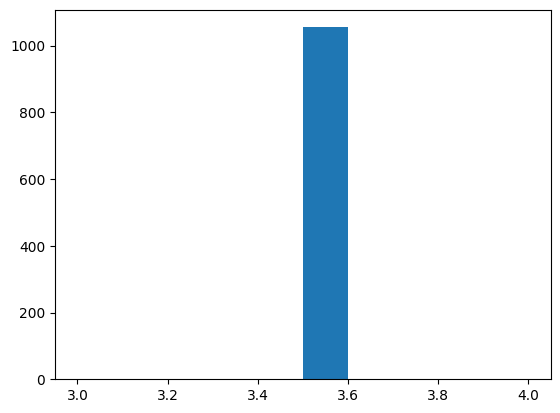

In [5]:
import matplotlib.pyplot as plt
plt.hist(beam_radius)

In [6]:
print(np.median(beam_radius))

3.5


In [7]:
print(coords_ARRAY[0])

[1.47900000e+03 3.43000000e+02 0.00000000e+00 4.95331129e-03]


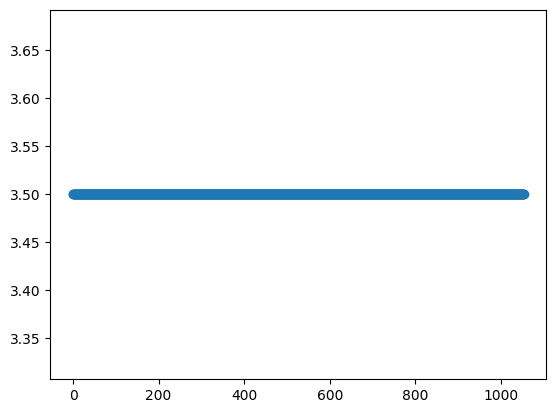

In [8]:
plt.scatter(np.arange(0,len(beam_radius)),beam_radius)

In [9]:
print(len(beam_radius))

1055


In [10]:
print(median_beam_radius)

3.5


In [11]:
print(len(final_dict))

26
